In [31]:
import pandas as pd
import rdata
from pathlib import Path

# Folder containing your .RData files
folder_notpen = Path("output/notpenalized")
folder_pen = Path("outputalsosmallgamma")

# List all .Rdata files
rdata_files_notpen = sorted(folder_notpen.glob("*.Rdata"))
all_data_notpen_censoradministrative = []
all_data_notpen_censornormal = []
all_data_notpen_censoruniform = []

rdata_files_pen = sorted(folder_pen.glob("*.Rdata"))
all_data_pen_censoradministrative = []
all_data_pen_censornormal = []
all_data_pen_censoruniform = []


for file in rdata_files_notpen:
    if "censoradministrative" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_notpen_censoradministrative.append(converted)
    elif "censornormal" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_notpen_censornormal.append(converted)
    elif "censoruniform" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_notpen_censoruniform.append(converted)



for file in rdata_files_pen:
    if "censoradministrative" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoradministrative.append(converted)
    elif "censornormal" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censornormal.append(converted)
    elif "censoruniform" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoruniform.append(converted)

/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1217: UserWarning: Unknown file type: assumed RDS
  warnings.warn("Unknown file type: assumed RDS")  # noqa: B028
/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1220: UserWarning: Wrong extension .Rdata for file in RDS format
  warnings.warn(f"Wrong extension {extension} for file in RDS format")  # noqa: B028


In [30]:
import pandas as pd
import numpy as np

records = []

for d in all_data_pen_censoradministrative:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "n_components": float(d["n_components"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'administrative'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

for d in all_data_pen_censornormal:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "n_components": float(d["n_components"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'normal'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

for d in all_data_pen_censoruniform:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "n_components": float(d["n_components"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'uniform'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

# build dataframe
df_pen = pd.DataFrame(records)
df_pen


,seed,c,k,gammapar,n_components,loglik,iterations,lambdaoptim,censor,estimate_0,estimate_1,estimate_2,estimate_3
0,0.0,3.0,20.0,1.000000e-03,3.0,-795.372050,3.0,1000.000000,administrative,1.050744,2.509115,0.000010,0.698357
1,0.0,3.0,20.0,1.000000e-01,3.0,-878.503257,34.0,117.925534,administrative,0.750998,1.737520,0.000398,0.438235
2,0.0,3.0,20.0,1.000000e-05,3.0,-793.804867,3.0,1000.000000,administrative,1.058303,2.528844,0.000009,0.704716
3,0.0,3.0,20.0,1.000000e-07,3.0,-793.788952,3.0,1000.000000,administrative,1.059279,2.529220,0.000009,0.704828
4,0.0,3.0,20.0,1.000000e-09,3.0,-793.788793,3.0,1000.000000,administrative,1.059279,2.529220,0.000009,0.704828
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,9.0,3.0,20.0,1.000000e-01,3.0,-1027.804497,31.0,97.372071,normal,0.598688,1.739716,0.000481,0.451339
1196,9.0,3.0,20.0,1.000000e-05,3.0,-926.194681,3.0,1440.000000,normal,0.620665,2.588357,0.000006,0.725151
1197,9.0,3.0,20.0,1.000000e-07,3.0,-926.160093,3.0,1440.000000,normal,0.621027,2.588661,0.000006,0.725276
1198,9.0,3.0,20.0,1.000000e-09,3.0,-926.159748,3.0,1440.000000,normal,0.621027,2.588661,0.000006,0.725276


### now we transform back the estimate_2 which is $\xi^\rho$ to make \xi

In [9]:
df_pen['estimate_2'] = df_pen['estimate_2']**(1/df_pen['estimate_1'])

In [10]:
df_pen

,seed,c,k,gammapar,n_components,loglik,iterations,lambdaoptim,censor,estimate_0,estimate_1,estimate_2,estimate_3
0,0.0,3.0,20.0,1.000000e-03,3.0,-795.372050,3.0,1000.000000,administrative,1.050744,2.509115,0.009995,0.698357
1,0.0,3.0,20.0,1.000000e-01,3.0,-878.503257,34.0,117.925534,administrative,0.750998,1.737520,0.011037,0.438235
2,0.0,3.0,20.0,1.000000e-05,3.0,-793.804867,3.0,1000.000000,administrative,1.058303,2.528844,0.009970,0.704716
3,0.0,3.0,20.0,1.000000e-07,3.0,-793.788952,3.0,1000.000000,administrative,1.059279,2.529220,0.009977,0.704828
4,0.0,3.0,20.0,1.000000e-09,3.0,-793.788793,3.0,1000.000000,administrative,1.059279,2.529220,0.009977,0.704828
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,9.0,3.0,20.0,1.000000e-01,3.0,-1027.804497,31.0,97.372071,normal,0.598688,1.739716,0.012385,0.451339
1196,9.0,3.0,20.0,1.000000e-05,3.0,-926.194681,3.0,1440.000000,normal,0.620665,2.588357,0.009793,0.725151
1197,9.0,3.0,20.0,1.000000e-07,3.0,-926.160093,3.0,1440.000000,normal,0.621027,2.588661,0.009789,0.725276
1198,9.0,3.0,20.0,1.000000e-09,3.0,-926.159748,3.0,1440.000000,normal,0.621027,2.588661,0.009789,0.725276


In [11]:
df_pen[df_pen.k == 20].groupby(['k'])['iterations'].value_counts()

k     iterations
20.0  3.0           662
      38.0           47
      40.0           46
      35.0           43
      36.0           43
      39.0           35
      41.0           35
      33.0           30
      37.0           28
      32.0           20
      42.0           19
      31.0           17
      34.0           16
      6.0            15
      29.0           14
      43.0           12
      26.0           11
      30.0           11
      4.0            10
      7.0            10
      28.0            9
      2.0             8
      25.0            8
      200.0           7
      27.0            6
      5.0             5
      56.0            4
      21.0            3
      49.0            3
      10.0            2
      22.0            2
      44.0            2
      53.0            2
      8.0             1
      9.0             1
      14.0            1
      18.0            1
      19.0            1
      23.0            1
      24.0            1
      45.0            1

In [12]:
df_pen[df_pen.k == 50].groupby(['k'])['iterations'].value_counts()

Series([], Name: count, dtype: int64)

In [13]:
import pandas as pd
import numpy as np

records = []

for d in all_data_notpen_censoradministrative:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'administrative'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

for d in all_data_notpen_censornormal:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'normal'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

for d in all_data_notpen_censoruniform:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'uniform'
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

# build dataframe
df_notpen = pd.DataFrame(records)
df_notpen

,seed,c,k,gammapar,loglik,iterations,lambdaoptim,censor,estimate_0,estimate_1,estimate_2,estimate_3
0,0.0,3.0,20.0,0.0,-793.788792,0.0,1000.0,administrative,1.059279,2.529220,0.000009,0.704828
1,0.0,3.0,50.0,0.0,-793.788792,0.0,1000.0,administrative,1.059279,2.529220,0.000009,0.704828
2,10.0,3.0,20.0,0.0,-886.795026,0.0,1000.0,administrative,0.614411,2.462905,0.000012,0.683281
3,10.0,3.0,50.0,0.0,-886.795026,0.0,1000.0,administrative,0.614411,2.462905,0.000012,0.683281
4,11.0,3.0,20.0,0.0,-842.560518,0.0,1000.0,administrative,0.714209,2.462628,0.000012,0.693482
...,...,...,...,...,...,...,...,...,...,...,...,...
595,98.0,3.0,50.0,0.0,-876.336817,0.0,1000.0,uniform,0.194501,2.533445,0.000010,0.701042
596,99.0,3.0,20.0,0.0,-980.684042,0.0,1000.0,uniform,0.839672,2.529161,0.000009,0.698438
597,99.0,3.0,50.0,0.0,-980.684042,0.0,1000.0,uniform,0.839672,2.529161,0.000009,0.698438
598,9.0,3.0,20.0,0.0,-886.693465,0.0,1000.0,uniform,0.602491,2.542613,0.000007,0.717589


### now we transform back the estimate_2 which is $\xi^\rho$ to make \xi

In [14]:
df_notpen['estimate_2'] = df_notpen['estimate_2']**(1/df_notpen['estimate_1'])

In [15]:
df = pd.concat([df_notpen, df_pen], axis = 0)

In [16]:
df

,seed,c,k,gammapar,loglik,iterations,lambdaoptim,censor,estimate_0,estimate_1,estimate_2,estimate_3,n_components
0,0.0,3.0,20.0,0.000000e+00,-793.788792,0.0,1000.000000,administrative,1.059279,2.529220,0.009977,0.704828,NaN
1,0.0,3.0,50.0,0.000000e+00,-793.788792,0.0,1000.000000,administrative,1.059279,2.529220,0.009977,0.704828,NaN
2,10.0,3.0,20.0,0.000000e+00,-886.795026,0.0,1000.000000,administrative,0.614411,2.462905,0.009931,0.683281,NaN
3,10.0,3.0,50.0,0.000000e+00,-886.795026,0.0,1000.000000,administrative,0.614411,2.462905,0.009931,0.683281,NaN
4,11.0,3.0,20.0,0.000000e+00,-842.560518,0.0,1000.000000,administrative,0.714209,2.462628,0.010128,0.693482,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,9.0,3.0,20.0,1.000000e-01,-1027.804497,31.0,97.372071,normal,0.598688,1.739716,0.012385,0.451339,3.0
1196,9.0,3.0,20.0,1.000000e-05,-926.194681,3.0,1440.000000,normal,0.620665,2.588357,0.009793,0.725151,3.0
1197,9.0,3.0,20.0,1.000000e-07,-926.160093,3.0,1440.000000,normal,0.621027,2.588661,0.009789,0.725276,3.0
1198,9.0,3.0,20.0,1.000000e-09,-926.159748,3.0,1440.000000,normal,0.621027,2.588661,0.009789,0.725276,3.0


In [17]:
df.n_components.value_counts()

n_components
3.0    1198
2.0       2
Name: count, dtype: int64

In [18]:
df.loc[df.gammapar!=0, 'n_components'].value_counts()

n_components
3.0    1198
2.0       2
Name: count, dtype: int64

In [19]:
df = df.loc[(df['n_components'] == 3) | (df['n_components'].isna())]

In [20]:
df = df.loc[(df['k'] == 20)] # ANALYSIS RESTRICTED TO K=20
df = df.loc[(df['gammapar'] != 0.5)]

<Axes: xlabel='gammapar', ylabel='loglik'>

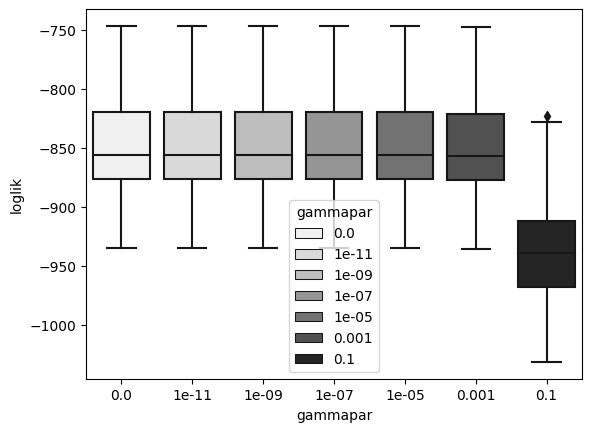

In [21]:

# Filter & convert
dfx = df.loc[df.censor == 'administrative', ['loglik', 'gammapar']].apply(pd.to_numeric, errors='coerce')
    
import seaborn as sns

sns.boxplot(
    data=dfx,
    x="gammapar",
    y='loglik',
    hue="gammapar",
    palette="Greys",
    dodge=False
)

## Bias of estimators

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# True parameter values
true_values = {
    'estimate_0': 0.5,
    'estimate_1': 2.5,
    'estimate_2': 0.01,
    'estimate_3': np.log(2)
}

# Define descriptive titles for each estimate
titles = {
    'estimate_0': r"(i) $\theta$", # r"Var$(u_g)$",
    'estimate_1': r"(ii) $\rho$",
    'estimate_2': r"(iii) $\xi$",
    'estimate_3': r"(iv) $\beta$"
}

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE  = 13

estimates = list(titles.keys())

for j in ['administrative', 'normal']:
    
    fig, axes = plt.subplots(
        1, len(estimates),
        figsize=(4.2 * len(estimates), 4.7),
        sharey=False
    )

    for ax, est in zip(axes, estimates):

        # Filter & convert
        dfx = df.loc[df.censor == j, [est, 'gammapar']].apply(pd.to_numeric, errors='coerce')
        
        sns.boxplot(
            data=dfx,
            x="gammapar",
            y=est,
            hue="gammapar",
            palette="Greys",
            dodge=False,  
            ax=ax
        )

        # True value
        ax.axhline(
            y=true_values[est],
            color='red',
            linestyle='--',
            label="True value"
        )

        # Clean subplot
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(f"{titles[est]}", fontsize=TITLE_SIZE)

        # REMOVE subplot legend (keep only global one)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()

    fig.subplots_adjust(bottom=0.15, top=0.8)

    fig.legend(
        handles, labels,
        title=r"$\gamma$",
        loc="lower center",
        ncol=len(labels),
        fontsize=TICK_SIZE,
        title_fontsize=TICK_SIZE
    )


    # Global title
    plt.suptitle(
        rf"Estimates $\hat{{p}}$ – {j} censoring",
        fontsize=TITLE_SIZE
    )

    fig.subplots_adjust(top=0.85, bottom=0.18)
    plt.savefig(f"Plots/Estimates_{j}.pdf", bbox_inches="tight")
    plt.close()


In [ ]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.ticker import ScalarFormatter

# # Modern clean style
# sns.set_style("whitegrid")
# #sns.set_context("talk")  

# # Define the true values for each estimate
# true_values = {
#     'estimate_0': 0.5,
#     'estimate_1': 2.5,
#     'estimate_2': 0.01,
#     'estimate_3': np.log(2)
# }

# # Define descriptive titles for each estimate
# titles = {
#     'estimate_0': r"(i) $\theta$", # r"Var$(u_g)$",
#     'estimate_1': r"(ii) $\rho$",
#     'estimate_2': r"(iii) $\xi$",
#     'estimate_3': r"(iv) $\beta$"
# }

# numb = {
#     'estimate_0': "(i)",
#     'estimate_1': "(ii)",
#     'estimate_2': "(iii)",
#     'estimate_3': "(iv)"
# }


# # Consistent style parameters
# TITLE_SIZE = 22
# LABEL_SIZE = 18
# TICK_SIZE  = 16


# for j in ['administrative', 'normal', 'uniform']:
#     for i in ['estimate_0', 'estimate_1', 'estimate_2', 'estimate_3']:
#         cols = [i, 'gammapar']
#         dfx = df.loc[df.censor==j, cols].apply(pd.to_numeric, errors='coerce')

#         # Plot using seaborn boxplot
#         plt.figure(figsize=(5.5, 6))
#         sns.boxplot(data=dfx, x='gammapar', y=i, palette='Greys')
        
#         # Overlay the true value as a horizontal line
#         plt.axhline(y=true_values[i], color='red', linestyle='--', label='True Value')

#         # Bigger text everywhere
#         plt.title(f"{numb[i]} {titles[i]} - {j} cens.", fontsize=TITLE_SIZE)
#         plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#         plt.ylabel(titles[i], fontsize=LABEL_SIZE)
#         plt.xticks(fontsize=TICK_SIZE)
#         plt.yticks(fontsize=TICK_SIZE)

#         #____
#         # get the tick locations (categories)
#         ax = plt.gca()
#         ticks = ax.get_xticks()

#         # original values from the dataframe
#         vals = dfx['gammapar'].unique()

#         # Sort to match seaborn order
#         vals = np.sort(vals)

#         # Create formatted labels
#         labels = []
#         for x in vals:
#             if x == 0:
#                 labels.append("0")
#             elif abs(x) < 0.01:
#                 exp = int(np.floor(np.log10(abs(x))))
#                 labels.append(rf"$10^{{{exp}}}$")
#             else:
#                 labels.append(f"{x:g}")

#         # Apply them
#         ax.set_xticklabels(labels, fontsize=TICK_SIZE)
#         #_________

#         # plt.show()
        
#         # Adjust legend so it shows only the true value
#         #plt.legend([f'True Value: {true_values[i]}'], loc='best')
        
#         plt.subplots_adjust(top=0.90, bottom=0.15)

#         # add enough space on the left so the y-label is fully visible
#         plt.gcf().subplots_adjust(left=0.2)

#         # Save the figure (PDF for LaTeX)
#         plt.savefig(f"Plots/Distribution_{j}_{i}.pdf", pad_inches=0.1)
#         plt.close()

        
    


## Bias-variance trade-off

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

for j in ['administrative', 'normal']:
    dfx = df[df.censor == j].copy()

    #_____________________
    # MSE

    # Define the true values for each estimate
    truevals = np.array([0.5, 2.5, 0.001, np.log(2)])

    # Compute L2 squared differences for each beta
    for i in range(4):
        dfx[f'diff_{i}'] = (dfx[f'estimate_{i}'] - truevals[i])**2

    # Melt dataframe to long format for plotting
    df_long = dfx.melt(
        id_vars=['gammapar'], 
        value_vars=['diff_0', 'diff_1', 'diff_2', 'diff_3'],
        var_name='Beta', 
        value_name='SquaredError'
    )

    # Clean up Beta names
    df_long['Beta'] = df_long['Beta'].map({'diff_0': r"(i) $\theta$", 'diff_1': r"(ii) $\rho$", 'diff_2': r"(iii) $\xi$", 'diff_3': r"(iv) $\beta$"})

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))

    # OLD VERSION
    # sns.boxplot(data=df_long, x='Beta', y='SquaredError', hue='gammapar', palette='Greys')
    # plt.title(f"(i) MSE  - {j} censoring", fontsize=TITLE_SIZE)
    # plt.xlabel("", fontsize=LABEL_SIZE)
    # plt.ylabel(r"$\|\hat{p} - p\|_2^2$", fontsize=LABEL_SIZE)

    # plt.xticks(fontsize=TICK_SIZE)
    # plt.yticks(fontsize=TICK_SIZE)

    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    # plt.legend(title=r'$\gamma$', fontsize=TICK_SIZE-3, title_fontsize=LABEL_SIZE-3)

    # # Save the figure (PDF for LaTeX)
    # plt.savefig(f"Plots/fig_MSE_{j}.pdf", bbox_inches="tight")
    # plt.close()

    # plt.show()


    betas = df_long['Beta'].unique()

    fig, axes = plt.subplots(
        1, len(betas),
        figsize=(4 * len(betas), 4.7),
        sharey=False
    )

    if len(betas) == 1:
        axes = [axes]

    for ax, beta in zip(axes, betas):
        df_sub = df_long[df_long['Beta'] == beta]

        sns.boxplot(
            data=df_sub,
            x="Beta",
            y="SquaredError",
            hue="gammapar",
            palette="Greys",
            ax=ax
        )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(beta, fontsize=TITLE_SIZE)

        # Remove legend in each subplot
        ax.get_legend().remove()

        handles, labels = axes[0].get_legend_handles_labels()

        fig.subplots_adjust(bottom=0.2, top=0.82)

        fig.legend(
            handles, labels,
            title=r"$\gamma$",
            loc="lower center",
            ncol=len(labels),
            fontsize=TICK_SIZE,
            title_fontsize=TICK_SIZE
        )

    plt.suptitle(
        rf"MSE $\|\hat{{p}} - p\|_2^2$ - {j} censoring",
        fontsize=TITLE_SIZE
    )

    # plt.show()
    # Save figure
    plt.savefig(f"Plots/fig_MSE_{j}.pdf", bbox_inches="tight")
    plt.close()



    #_____________________
    # VARIANCE

    # Keep relevant columns
    df_true = dfx[['seed', 'gammapar', 'estimate_0', 'estimate_1', 'estimate_2', 'estimate_3']].copy()

    # --- Compute squared deviations by gammapar ---
    for i in range(4):
        col = f'estimate_{i}'
        # Compute mean per gammapar group
        df_true[f'{col}_mean'] = df_true.groupby('gammapar')[col].transform('mean')
        # Compute squared deviation from that mean
        df_true[f'{col}'] = (df_true[col] - df_true[f'{col}_mean'])**2

    # --- Melt to long format for plotting ---
    df_long = df_true.melt(
        id_vars=['gammapar'],
        value_vars=['estimate_0', 'estimate_1', 'estimate_2', 'estimate_3'],
        var_name='Beta',
        value_name='SquaredDeviation'
    )

    # Clean up Beta names
    df_long['Beta'] = df_long['Beta'].map(titles)

    # --- Plotting ---
    plt.figure(figsize=(6, 6))
    # OLD VERSION
    # sns.boxplot(data=df_long, x='Beta', y='SquaredDeviation', hue='gammapar', palette='Greys')

    #**********************************************
    # Get unique parameters in the order you want
    betas = df_long['Beta'].unique()

    # One subplot per Beta
    fig, axes = plt.subplots(1, len(betas), figsize=(4 * len(betas), 4.7), sharey=False)

    if len(betas) == 1:
        axes = [axes]  

    for ax, beta in zip(axes, betas):
        df_sub = df_long[df_long['Beta'] == beta]

        sns.boxplot(
            data=df_sub,
            x="Beta",
            y="SquaredDeviation",
            hue="gammapar",
            palette="Greys",
            ax=ax
        )
        ax.set_title(beta)
        ax.set_xlabel("")
        ax.set_ylabel("") #r"$\|\hat{p} - \bar{\hat{p}}\|_2^2$")

        ax.set_xticks([])         # remove tick positions
        ax.set_xticklabels([])    # remove tick labels

        # Title (keep it)
        ax.set_title(beta, fontsize=14)
        ax.get_legend().remove()

    # Move legend outside
    handles, labels = axes[0].get_legend_handles_labels()

    fig.subplots_adjust(bottom=0.2, top=0.82) 
    fig.legend(
        handles, labels, title=r"$\gamma$",
        loc="lower center",
        ncol=len(labels),
        fontsize=TICK_SIZE,
        title_fontsize=TICK_SIZE
        #bbox_to_anchor=(0.5, 0.02) #,   # push legend further down
        #frameon=False
    )

    plt.suptitle(rf"Variance $\|\hat{{p}} - \bar{{\hat{{p}}}}\|_2^2$ - {j} censoring", fontsize=TITLE_SIZE)

    # plt.show()
    # Save the figure (PDF for LaTeX)
    plt.savefig(f"Plots/fig_Variance_{j}.pdf", bbox_inches="tight")
    plt.close()

    #*********************************************

    # OLD VERSION
    # plt.title(f"(ii) Variance - {j} censoring", fontsize=TITLE_SIZE)
    # plt.xlabel("", fontsize=LABEL_SIZE)
    # plt.ylabel(r"$\|\hat{p} - \bar{\hat{p}}\|_2^2$", fontsize=LABEL_SIZE)

    # plt.yticks(fontsize=TICK_SIZE)

    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    # # plt.legend(title=r'$\gamma$', fontsize=TICK_SIZE-3, title_fontsize=LABEL_SIZE-3)

    # # Save the figure (PDF for LaTeX)
    # plt.savefig(f"Plots/fig_Variance_{j}.pdf", bbox_inches="tight")
    # plt.close()

    # plt.show()




<Figure size 1000x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

## Accuracy

In [25]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import rdata
from pathlib import Path

# Folder containing your .RData files
folder_pen = Path("outputalsosmallgamma")

# List all .Rdata files
rdata_files_pen = sorted(folder_pen.glob("*.Rdata"))
all_data_pen_censoradministrative = []
all_data_pen_censornormal = []
all_data_pen_censoruniform = []


for file in rdata_files_pen:
    if "censoradministrative" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoradministrative.append(converted)
    elif "censornormal" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censornormal.append(converted)
    elif "censoruniform" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoruniform.append(converted)



In [26]:
def simple_relabel(true_labels, pred_labels):
    """
    Relabel predicted clusters to match true labels based on maximum overlap.
    Works when number of clusters is small (e.g., 3) and you just want names to match.
    """
    true_labels = pd.Series(true_labels)
    pred_labels = pd.Series(pred_labels)
    
    unique_true = true_labels.unique()
    unique_pred = pred_labels.unique()
    
    mapping = {}
    used_true = set()
    
    for p in unique_pred:
        # find the true label with max overlap
        overlaps = {t: ((true_labels==t) & (pred_labels==p)).sum() for t in unique_true if t not in used_true}
        best_true = max(overlaps, key=overlaps.get)
        mapping[p] = best_true
        used_true.add(best_true)
    
    new_preds = pred_labels.map(mapping)
    return new_preds, mapping

In [27]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

gammapars_all = {}
accuracy_all = {}
ari_all = {}
nmi_all = {}

numb = {
    'admin': "(i) Administrative censoring",
    'norm': "(ii) Normal censoring",
    'unif': "(iii) Uniform censoring"
}


for j,name in [(all_data_pen_censoradministrative, "admin"), (all_data_pen_censornormal, "norm"), (all_data_pen_censoruniform, "unif")]:
    datasets = []
    gammapars = []
    for d in j:
        if d["n_components"] == 3 and d["k"] == 20:
            if d['gammapar'] != 0.5:
                datasets.append(pd.DataFrame(d["clusters"]))
                gammapars.append(d["gammapar"][0])

        
    accuracy_list = []
    nmi_list = []
    ari_list = []

    for df in datasets:
        # Extract the two cluster membership columns
        true_labels = df.iloc[:, 0]
        pred_labels = df.iloc[:, 1]

        # Align predicted clusters to true clusters
        aligned_preds, mapping = simple_relabel(true_labels, pred_labels)

        # Add an indicator column for exact matches
        df["same_membership"] = (true_labels == aligned_preds).astype(int)


        # Compute metrics
        nmi = normalized_mutual_info_score(true_labels, aligned_preds)
        print(f"NMI: {nmi:.3f}")
        nmi_list.append(nmi)

        ari = adjusted_rand_score(true_labels, aligned_preds)
        print(f"ARI: {ari:.3f}") 
        ari_list.append(ari)   

        accuracy = df["same_membership"].mean()
        print(f"Accuracy: {accuracy:.3f}")   
        accuracy_list.append(accuracy)

        print('\n')

    
    gammapars_all[f"{name}"] = np.array(gammapars)
    accuracy_all[f"{name}"] = np.array(accuracy_list)
    ari_all[f"{name}"] = np.array(ari_list)
    nmi_all[f"{name}"] = np.array(nmi_list)


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 0.748
ARI: 0.660
Accuracy: 0.844


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000




In [295]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"Accuracy": accuracy_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="Accuracy",
#         palette="Greys"
#     )



#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("Accuracy", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_Accuracy_{j}.pdf", bbox_inches="tight")
#     plt.close()



In [296]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"ARI": ari_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="ARI",
#         palette="Greys"
#     )

#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("ARI", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_ARI_{j}.pdf", bbox_inches="tight")
#     plt.close()

In [297]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"NMI": nmi_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="NMI",
#         palette="Greys"
#     )


#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("NMI", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_NMI_{j}.pdf", bbox_inches="tight")
#     plt.close()

In [28]:
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

titles_acc = {
    'admin': "(i) Accuracy – Administrative cens.",
    'norm':  "(ii) Accuracy – Normal cens.",
}

titles_ari = {
    'admin': "(iii) ARI – Administrative cens.",
    'norm':  "(iv) ARI – Normal cens.",
}

# -------------------------------
# Create 2×2 figure
# -------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

# store gamma values once
gammas_used = None

# --------------------------------
# First row: ACCURACY
# --------------------------------
for col, j in enumerate(['admin', 'norm']):

    df_acc = pd.DataFrame({
        "Value": accuracy_all[j],
        "Gamma": gammapars_all[j]
    })

    if gammas_used is None:
        gammas_used = np.sort(df_acc["Gamma"].unique())

    sns.boxplot(
        data=df_acc,
        x="Gamma",
        y="Value",
        palette="Greys",
        ax=axes[col]
    )

    ax = axes[col]
    ax.set_title(titles_acc[j], fontsize=TITLE_SIZE-5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_xticklabels([])

# --------------------------------
# Second row: ARI
# --------------------------------
for col, j in enumerate(['admin', 'norm']):

    df_ari = pd.DataFrame({
        "Value": ari_all[j],        # your ARI values here
        "Gamma": gammapars_all[j]
    })

    sns.boxplot(
        data=df_ari,
        x="Gamma",
        y="Value",
        palette="Greys",
        ax=axes[col+2]
    )

    ax = axes[col+2]
    ax.set_title(titles_ari[j], fontsize=TITLE_SIZE-5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_xticklabels([])

# --------------------------------
# Build the global gamma legend
# --------------------------------
colors = sns.color_palette("Greys", len(gammas_used))

labels = []
for g in gammas_used:
    if g == 0:
        labels.append("0")
    elif abs(g) < 0.01:
        e = int(np.floor(np.log10(abs(g))))
        labels.append(rf"$10^{{{e}}}$")
    else:
        labels.append(f"{g:g}")

handles = [
    mpatches.Patch(facecolor=colors[k], label=labels[k], 
                   edgecolor="black",  
                   linewidth=0.5)
    for k in range(len(gammas_used))
]

fig.legend(
    handles,
    labels,
    title=r"$\gamma$",
    loc="lower center",
    ncol=len(labels),
    fontsize=TICK_SIZE,
    title_fontsize=TICK_SIZE
)

# Add spacing and global title
fig.subplots_adjust(top=0.85, bottom=0.28)

#fig.suptitle("Accuracy and ARI – Censoring Comparison", fontsize=TITLE_SIZE)

plt.savefig("Plots/Fig_Accuracy_ARI_All.pdf", bbox_inches="tight")
plt.close()
